# Fundamentos de Machine Learning – Trabajo Práctico Nro. 2

## Ejercicio 1
La juguetería Gaby desea estimar mediante regresión lineal simple las ventas para el mes
de Julio de su nuevo carrito infantil "Mate". La información del comportamiento de las
ventas de todos sus almacenes de cadena se presenta en el siguiente tabulado:
Determinar el pronóstico para el mes de venta nro. 7.

In [3]:
# importar todas las librería necesarias para desarrollar el ejercicio:
import pandas as pd # Cargar librería Pandas con el alias 'pd' para trabajar con archivos de datos.
import numpy as np # Cargar librería NumPy con el alias 'np' para el cálculo numérico y el análisis de datos.
import matplotlib.pyplot as plt # Cargar librería para representar gráficamente la salida del algoritmo.
from sklearn.model_selection import train_test_split # para dividir en Testing o Training.
from sklearn.linear_model import LinearRegression # Mi algoritmo de clasificación.
from sklearn.metrics import mean_squared_error, r2_score # Para las métricas.



Coeficiente correlacion:
	 0.729

Pendiente:
	 1114.29

Intecept:
	 5266.67

Mean squared error:
	 3184126.98

Coefficient of determination:
	 0.53

Predicción de venta Mes 7 =
	 13066.67


/tmp/ipykernel_168/3662858103.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('\nPendiente:\n\t %0.2f' %regressor.coef_) # Pendiente
/tmp/ipykernel_168/3662858103.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('\nIntecept:\n\t %0.2f' %regressor.intercept_) # Intercept
/tmp/ipykernel_168/3662858103.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("\nPredicción de venta Mes 7 =\n\t %0.2f" %regressor.predict([[7]])) # predicción para e

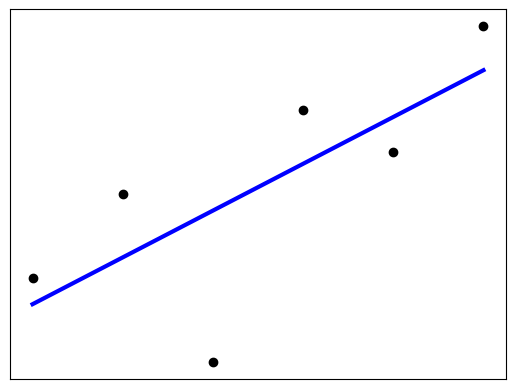

y(Ventas) = (1114.29 * X) + 5266.67


/tmp/ipykernel_168/3662858103.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('y(Ventas) = (%0.2f * X) + %0.2f' %(regressor.coef_,regressor.intercept_))


In [4]:
#--------------------------------------------------------------------------------------------------------
ventasData = pd.read_csv("../Clase 09 - ventas.csv", sep=",", encoding="latin-1")
CR = ventasData['Mes'].corr(ventasData['Ventas']) # Coeficiente de correlación
X=ventasData['Mes'].values.reshape(-1,1) # Obtengo los valores de Mes normalizando los datos, entre -1 y 1
y=ventasData['Ventas'].values.reshape(-1,1) # Obtengo los valores de las Ventas normalizando los datos, entre -1 y 1
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 7) # import train_test_split
#regressor.fit(X_train, y_train) # Entreno el modelo usando el set de datos de training
#y_Pred = regressor.predict(X_train) # Predicción
regressor = LinearRegression()  # Creo el objeto linear regression
regressor.fit(X, y) # Entreno el modelo usando todo el set de datos
y_Pred = regressor.predict(X) # Predicción
print("\nCoeficiente correlacion:\n\t %.3f" %(CR)) # Coeficiente de correlacion
print('\nPendiente:\n\t %0.2f' %regressor.coef_) # Pendiente
print('\nIntecept:\n\t %0.2f' %regressor.intercept_) # Intercept
#print('\nMean squared error:\n\t %.2f' % mean_squared_error(y_train, y_Pred)) # mean squared error
#print('\nCoefficient of determination:\n\t %.2f' % r2_score(y_train, y_Pred)) # Coefficient of determination: 1 is perfect prediction
print('\nMean squared error:\n\t %.2f' % mean_squared_error(y, y_Pred)) # mean squared error
print('\nCoefficient of determination:\n\t %.2f' % r2_score(y, y_Pred)) # Coefficient of determination: 1 is perfect prediction
print("\nPredicción de venta Mes 7 =\n\t %0.2f" %regressor.predict([[7]])) # predicción para el mes 7

#--------------------------------------------------------------------------------------------------------
# Plot outputs
#plt.scatter(X_train, y_train,  color='black')
#plt.plot(X_train, y_Pred, color='blue', linewidth=3)
plt.scatter(X, y,  color='black')
plt.plot(X, y_Pred, color='blue', linewidth=3)
plt.xticks(())
plt.yticks(())
plt.show()

#--------------------------------------------------------------------------------------------------------
print('y(Ventas) = (%0.2f * X) + %0.2f' %(regressor.coef_,regressor.intercept_))

# EJERCICIO 2
Realizar un clasificador Random Forest para predecir si una flor es vertiginosa, setosa o virginica. Utilizar el dataset “iris.csv”.

In [ ]:
#Quiero construir un modelo en base a datos del pétalo y del sépalo
#--------------------------------------------------------------------------------------------------------
# importar todas las librería necesarias para desarrollar el ejercicio:
from sklearn import datasets # importar sklearn
from sklearn.model_selection import train_test_split # para dividir en Testing o Training.
from sklearn.ensemble import RandomForestClassifier # Mi algoritmo de clasificación.
from sklearn import metrics # Para las métricas.
#--------------------------------------------------------------------------------------------------------
print("Inicio\n")
iris = datasets.load_iris() #Para importar los datasets / The iris dataset is a classic and very easy multi-class classification dataset.
print("Categorías de la Salida:\n\t", iris.target_names) #Categorías de la Salida
print("Features de entrada:\n\t",iris.feature_names) #Features de entrada
print("Datos de iris (top 5):\n",iris.data[0:5]) #Datos de iris (top 5)
print("Output iris labels (0:setosa, 1:versicolor, 2:virginica):\n\t",iris.target) # Output labels (0:setosa, 1:versicolor, 2:virginica)
#--------------------------------------------------------------------------------------------------------
#Crea un DataFrame a través de Pandas
import pandas as pd
data = pd.DataFrame({'Sepal length':iris.data[:,0],
                     'Sepal width':iris.data[:,1],
                     'Petal length':iris.data[:,2],
                     'Petal width':iris.data[:,3],
                     'Species':iris.target})
data.head() #Visualizar las primeras 5 lineas de los datos cargados
X=data[['Sepal length', 'Sepal width', 'Petal length', 'Petal width']] #feautures
y=data['Species'] #Labels
#--------------------------------------------------------------------------------------------------------
# Split dataset into training set and test set
# X=es el vector de datos / 80% training, 20% test
# train_test_split ( los datos, la variable dependiente, test_size=0.4, random_state=0 )
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
#--------------------------------------------------------------------------------------------------------
# Algoritmos de Machine Learning: 4 pasos.
clf = RandomForestClassifier(n_estimators=100) #Crea un clasificador Gaussiano
clf.fit(X_train,y_train) # fit = Para entrenar el modelo - utiliza los datos de entrenamoiento
ypredict = clf.predict(X_test) # y_pred = clf.predict(X_test) - utiliza los datos de testeo
print('Accuracy: ',metrics.accuracy_score(y_test, ypredict))
#--------------------------------------------------------------------------------------------------------
#prediccion
Pred=clf.predict([[2, 3, 4, 5]])
#imprime las etiquetas 0:setosa 1:versicolor 2:virginica
if Pred == 0:
  print('La flor es setosa')
elif Pred == 1:
  print('La flor es vertiginosa')
else:
  print('La flor es virginica')

Inicio

Categorías de la Salida:
	 ['setosa' 'versicolor' 'virginica']
Features de entrada:
	 ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Datos de iris (top 5):
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Output iris labels (0:setosa, 1:versicolor, 2:virginica):
	 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
Accuracy:  0.9333333333333333
La flor es virginica


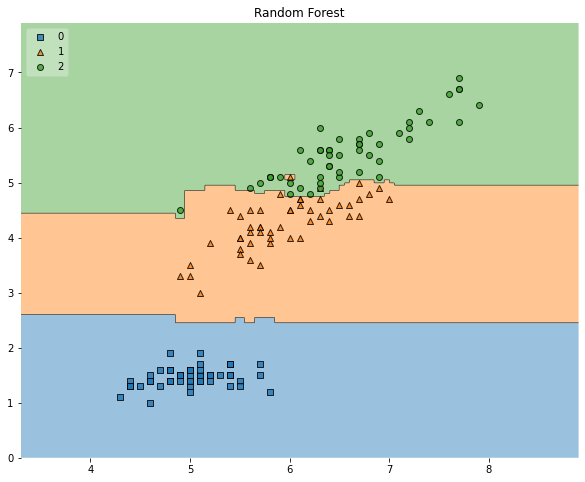

In [ ]:
#Quiero visualizar el resultado de la clasificación Random Forest.
#--------------------------------------------------------------------------------------------------------
import matplotlib.pyplot as plt # Para graficar.
from mlxtend.data import iris_data # Para importar los datasets.
from sklearn.ensemble import RandomForestClassifier # Mi algoritmo de clasificación.
#--------------------------------------------------------------------------------------------------------
clfx = RandomForestClassifier(random_state=0) # Mi algoritmo de clasificación.
#--------------------------------------------------------------------------------------------------------
X, y = iris_data() # Para importar los datasets
X = X[:,[0, 2]] # Acomodo los datos para poder graficarlos
fig = plt.figure(figsize=(10, 8)) # Defino el área del gráfico
labels = ['Random Forest'] # Título del gráfico.
clfx.fit(X, y) # fit = Para entrenar el modelo.
fig = plot_decision_regions(X=X, y=y,clf=clfx, legend=2) # graficando el resultado.
plt.title(lab) # Muestro el contenido de Labels
plt.show() # Muestro el gráfico

# EJERCICIO 3

Dado el siguiente código en python, explique con sus palabras lo que se hace en cada línea de código:

In [2]:
# Usando 2 técnicas de particion de datos, veo cuál es más precisa.
# cross_val_Score o cross_val_predict
#--------------------------------------------------------------------------------------------------------
from sklearn.datasets import load_iris # importar sklearn, podré acceder a la data y a target.
from sklearn import tree  # Mi algoritmo de clasificación del arbol de decisión.
from sklearn.model_selection import cross_val_score # método cross_val_score
from sklearn.model_selection import train_test_split # para dividir datos en Testing o Training.
from sklearn.model_selection import cross_val_predict # método cross_val_predict
from sklearn.metrics import confusion_matrix # metrica de matrices de confusión
#--------------------------------------------------------------------------------------------------------
iris = load_iris() # Se carga el dataset Iris.
#--------------------------------------------------------------------------------------------------------
# Split dataset: training set + test set
# Argumentos:
#    iris.data = variables independiente o datos de entrada (todas las columnas menos la última)
#    iris.data = la variable dependiente (la última columna)
#    test_size=0.4
#    Este método va a devolver 4 variables:
#    X_train (el 60% de las filas)
#    X_test (el 40% de las filas)
#    y_train (el 60% de las de target)
#    y_test (el 40% de las filas)
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target,test_size=0.4, random_state=0)
clf = tree.DecisionTreeClassifier() # Asignacion de modelo de clasificación - crea un clasificador.
clf = clf.fit(X_train, y_train) # Entrenamiento del modelo con el 60% de las variables independientes.
print("Accuracy1: %0.2f" % clf.score(X_test, y_test)) # Para comprobar si está bien entrenado.
clf.predict(X_test) # Imprime el clasificador con test
clf = tree.DecisionTreeClassifier() #asignacion de modelo de clasificación - crea otro clasificador.
# Ahora uso otro método de división: cross_val_score (está importado arriba)
# features = iris.data,
# target = iris.target,
scores = cross_val_score(clf, iris.data,iris.target, cv=5)
# Mejora el accuracy = 0,97 – con esto veo que 2 métodos diferentes tienen distinto Accuracy
print("Accuracy2: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 2)) #muestra el valor del Accuracy para éste método
#--------------------------------------------------------------------------------------------------------
#Entrenamiento y prueba del modelo clasificación
y_pred = clf.fit(X_train,y_train).predict(X_test) #entrenamiento del modelo y predicción en 1 paso, con Split
conf_matrix_1 = confusion_matrix(y_test, y_pred) #calculo matriz de confusión - para sacar métricas, voy a usar (y_test, y_pred)
print(conf_matrix_1) #Se presenta la matriz de confusión para validar cuantos aciertos en las clasificaciones predichas tuvo el modelo con este tipo de partición
# usa un % para test (16 + 23 + 21) debe ser el 40% de los datos)
#--------------------------------------------------------------------------------------------------------
#Entrenamiento y prueba del modelo clasificación con método Cross_val_predict
y_pred = cross_val_predict(clf, iris.data,iris.target, cv=5) #predicción de cross validation (sin split)
conf_matrix_2 = confusion_matrix(iris.target, y_pred) #calculo matriz de confusión
print(conf_matrix_2) #Se presenta la matriz de confusión para validar cuantos aciertos en las clasificaciones predichas tuvo el modelo con este tipo de partición
# prueba todos los datos (50, 50, 50)
# 50 es la primera categoría, los 50 fueron clasificados bien.
# En la de 48, se equivocó en 2
# En 46, se equivocó en 4
#--------------------------------------------------------------------------------------------------------

Accuracy1: 0.95
Accuracy2: 0.96 (+/- 0.07)
[[16  0  0]
 [ 0 22  1]
 [ 0  2 19]]
[[50  0  0]
 [ 0 48  2]
 [ 0  3 47]]
